# **32147009 - Maryam Saeed- Databases and Analytics**

# **Python Data Processing**

**Importing Required Libraries**

The required Python libraries were imported to support data loading, processing, and visualisation tasks. Pandas was used for dataframe operations, NumPy for numerical processing, and Matplotlib for generating charts and visualisations.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Uploading Dataset Files**

The dataset files were uploaded into the Google Colab environment to enable further preprocessing and analysis. These files contain operational data related to the NorthStar Urban Mobility system.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving app_events.csv to app_events.csv
Saving complaints.csv to complaints.csv
Saving customers.csv to customers.csv
Saving deliveries.csv to deliveries.csv
Saving drivers.csv to drivers.csv
Saving hubs.csv to hubs.csv
Saving incidents.csv to incidents.csv
Saving orders.csv to orders.csv
Saving vehicles.csv to vehicles.csv


**Loading Datasets into DataFrames**

All CSV files were loaded into separate Pandas dataframes for processing and analysis. Each dataframe represents a different operational entity such as orders, deliveries, customers, vehicles, drivers, complaints, hubs, incidents, and app events. This structured approach improves data organisation and supports efficient analysis.

In [ ]:
# Read all the files
app_events = pd.read_csv("app_events.csv")
complaints = pd.read_csv("complaints.csv")
customers = pd.read_csv("customers.csv")
deliveries = pd.read_csv("deliveries.csv")
drivers = pd.read_csv("drivers.csv")
hubs = pd.read_csv("hubs.csv")
incidents = pd.read_csv("incidents.csv")
orders = pd.read_csv("orders.csv")
vehicles = pd.read_csv("vehicles.csv")

print("✅ All files loaded")

✅ All files loaded


**Dataset Overview and Missing Value Analysis**

This step analyses the structure of each dataset by displaying the total number of rows and columns. It also identifies missing values across all datasets to detect incomplete or inconsistent data that may affect analysis accuracy. Understanding missing values helps improve data quality before further processing.

In [ ]:
print("======================================================")
print("DATASET OVERVIEW & MISSING VALUES")
print("======================================================")

for name, df in [("app_events", app_events),
                 ("complaints", complaints),
                 ("customers", customers),
                 ("deliveries", deliveries),
                 ("drivers", drivers),
                 ("hubs", hubs),
                 ("incidents", incidents),
                 ("orders", orders),
                 ("vehicles", vehicles)]:

    print(f"\nDATASET: {name}")

    # Total rows and columns
    print(f"Total Rows    : {df.shape[0]}")
    print(f"Total Columns : {df.shape[1]}")

    # Missing values
    missing = df.isnull().sum()
    missing = missing[missing > 0]

    if not missing.empty:
        print("\nMissing Columns:")
        print(missing.to_string())
    else:
        print("\nNo Missing Values")

DATASET OVERVIEW & MISSING VALUES

DATASET: app_events
Total Rows    : 640
Total Columns : 10

Missing Columns:
order_id    144

DATASET: complaints
Total Rows    : 320
Total Columns : 10

Missing Columns:
compensation_amount    16

DATASET: customers
Total Rows    : 650
Total Columns : 9

Missing Columns:
loyalty_score        20
preferred_channel    13

DATASET: deliveries
Total Rows    : 950
Total Columns : 13

Missing Columns:
delivery_completed_at            19
customer_rating_post_delivery    14

DATASET: drivers
Total Rows    : 170
Total Columns : 8

Missing Columns:
training_score    7

DATASET: hubs
Total Rows    : 8
Total Columns : 5

No Missing Values

DATASET: incidents
Total Rows    : 280
Total Columns : 7

Missing Columns:
resolved_hours    17

DATASET: orders
Total Rows    : 1250
Total Columns : 11

Missing Columns:
booking_channel    25

DATASET: vehicles
Total Rows    : 120
Total Columns : 8

Missing Columns:
battery_health_pct    4


**Identifying Zone Inconsistencies**

This step examines zone-related columns across multiple datasets to identify inconsistent naming formats and duplicate representations of the same geographic areas. Detecting these inconsistencies is important to ensure accurate grouping, filtering, and analysis of operational data across different zones.


In [ ]:
print("======================================================")
print("ZONE INCONSISTENCIES")
print("======================================================")
for name, df, col in [
    ("customers",  customers,  "home_zone"),
    ("drivers",    drivers,    "base_zone"),
    ("vehicles",   vehicles,   "assigned_zone"),
    ("orders",     orders,     "pickup_zone"),
    ("orders",     orders,     "dropoff_zone"),
    ("app_events", app_events, "zone_context"),
]:
    print(f"\n{name} → {col}:")
    print(sorted(df[col].dropna().unique()))

ZONE INCONSISTENCIES

customers → home_zone:
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

drivers → base_zone:
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

vehicles → assigned_zone:
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

orders → pickup_zone:
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

orders → dropoff_zone:
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

app_events → zone_context:
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAS

**Filling Missing Values**

Missing values were identified and handled across multiple datasets to improve data quality and ensure accurate analysis. Different techniques such as replacing missing values with median, mode, zero values, or default labels were applied depending on the data type and business meaning of each attribute.

In [ ]:
# app_events - fill order_ind with NoOrder
app_events['order_id'] = app_events['order_id'].fillna("NoOrder")

# complaints - fill compensation_amount with 0
complaints['compensation_amount'] = complaints['compensation_amount'].fillna(0)

# customers - fill loyalty_score with median and preferred_channel with mode
customers['loyalty_score'] = customers['loyalty_score'].fillna(customers['loyalty_score'].median())
customers['preferred_channel'] = customers['preferred_channel'].fillna(customers['preferred_channel'].mode()[0])

# deliveries - fill customer_rating_post_delivery and leave delivery_completed_at as NaT (failed deliveries)
deliveries['customer_rating_post_delivery'] = deliveries['customer_rating_post_delivery'].fillna(0)

# drivers- fill training_score with median
drivers['training_score'] = drivers['training_score'].fillna(drivers['training_score'].median())

# incidents - fill with median
incidents['resolved_hours'] = incidents['resolved_hours'].fillna(incidents['resolved_hours'].median())

# orders - fill booking_channel with mode
orders['booking_channel'] = orders['booking_channel'].fillna(orders['booking_channel'].mode()[0])

# vehicles - fill battery_health_pct with median
vehicles['battery_health_pct'] = vehicles['battery_health_pct'].fillna(vehicles['battery_health_pct'].median())

print("✅ All the missing values filled")

✅ All the missing values filled


**Fixing Zone Inconsistencies**

Zone inconsistencies were corrected by standardising zone names across all datasets. Different representations of the same geographic zones were converted into a consistent format to avoid errors during grouping, filtering, and analysis operations.

In [ ]:
# Fixing the inconsistencies
def fix_zone(zone):
    zone = str(zone).strip().upper()

    if zone == "NORTH":
        return "North"
    elif zone == "SOUTH":
        return "South"
    elif zone == "EAST":
        return "East"
    elif zone == "WEST":
        return "West"
    elif zone in ["CENTRAL", "CTR"]:
        return "Central"
    elif zone == "AIRPORT":
        return "Airport"
    elif zone == "RIVERSIDE":
        return "RiverSide"
    else:
        return zone.title()

# Applying
app_events['zone_context'] = app_events['zone_context'].apply(fix_zone)
customers['home_zone'] = customers['home_zone'].apply(fix_zone)
orders['pickup_zone'] = orders['pickup_zone'].apply(fix_zone)
orders['dropoff_zone'] = orders['dropoff_zone'].apply(fix_zone)
drivers['base_zone'] = drivers['base_zone'].apply(fix_zone)
vehicles['assigned_zone'] = vehicles['assigned_zone'].apply(fix_zone)

print("✅ Zone inconsistencies fixed")

✅ Zone inconsistencies fixed


**Datetime Parsing**

Date and time columns were converted into proper datetime format to support time-based analysis and calculations. This step enables operations such as extracting months, calculating delivery durations, and analysing trends over time.

In [ ]:
# Parse datetime columns
datetime_cols = {
    'customers':  ['signup_date'],
    'orders':     ['order_created_at'],
    'deliveries': ['dispatch_time', 'delivery_completed_at'],
    'complaints': ['created_at'],
    'incidents':  ['reported_at'],
    'app_events': ['event_timestamp'],
    'vehicles':   ['commission_date'],
}

for name, cols in datetime_cols.items():
    df = eval(name)
    for col in cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    exec(f"{name} = df")

print("✅ Datetime columns parsed")

✅ Datetime columns parsed


**Feature Engineering**

New features were created to improve analytical insights and support deeper operational analysis. These features include delivery duration, monthly order trends, customer tenure, and vehicle battery risk categories. Feature engineering helps identify patterns and operational risks more effectively.

In [ ]:
# Delivery time taken in hours
deliveries['actual_duration_hrs'] = (
    deliveries['delivery_completed_at'] - deliveries['dispatch_time']
).dt.total_seconds() / 3600

# Monthly orders per zone
orders['order_month'] = orders['order_created_at'].dt.month
zone_monthly_orders = (
    orders[['pickup_zone', 'order_month']]
    .value_counts()
    .reset_index(name='order_count')
)

# Customer tenure in days
customers['tenure_days'] = (
    pd.Timestamp.now() - customers['signup_date']
).dt.days

# Categorise vehicle battery health
vehicles['battery_risk'] = pd.cut(
    vehicles['battery_health_pct'],
    bins=[0, 40, 70, 100],
    labels=['High Risk', 'Medium Risk', 'Low Risk']
)

print("✅ Features engineered")

✅ Features engineered


### **Python Analysis & Visualisations**

**Chart 1 - Failed Deliveries by Zone**

This chart analyses the number of failed deliveries across different pickup zones. It helps identify geographic areas with higher delivery failure rates and highlights zones that may require operational improvements, route optimisation, or additional delivery resources.

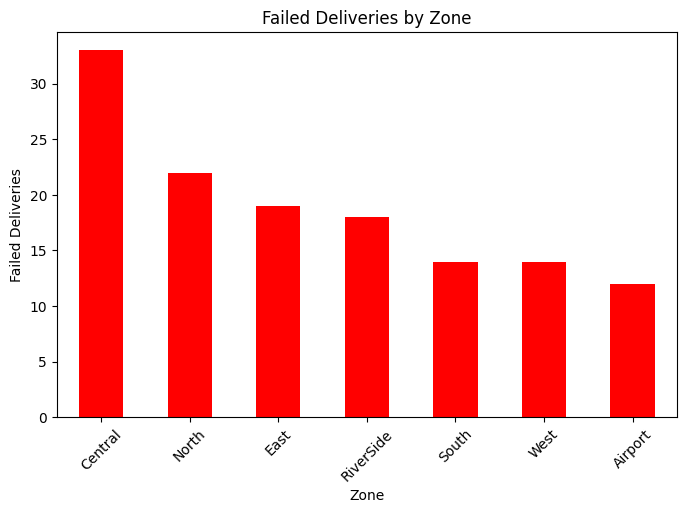

In [ ]:
# CHART 1 - Failed Deliveries by Zone
failed = deliveries.merge(
    orders[['order_id', 'pickup_zone']],
    on='order_id'
)

failed = failed[failed['delivery_status'] == 'Failed']

failed_zone = failed['pickup_zone'].value_counts()

plt.figure(figsize=(8,5))

failed_zone.plot(kind='bar', color='red')

plt.title('Failed Deliveries by Zone')
plt.xlabel('Zone')
plt.ylabel('Failed Deliveries')

plt.xticks(rotation=45)

plt.show()

In [ ]:
# Merge to get zone info
failed = deliveries.merge(
    orders[['order_id', 'pickup_zone']],
    on='order_id'
)

# Filter failed deliveries
failed = failed[failed['delivery_status'] == 'Failed']

# Count failed deliveries per zone
zone_counts = failed['pickup_zone'].value_counts()

# Convert to DataFrame
zone_summary = zone_counts.reset_index()
zone_summary.columns = ['pickup_zone', 'failed_deliveries']

# Calculate percentage
zone_summary['percentage'] = (
    zone_summary['failed_deliveries'] / zone_summary['failed_deliveries'].sum() * 100
).round(1)

print(zone_summary)

  pickup_zone  failed_deliveries  percentage
0     Central                 33        25.0
1       North                 22        16.7
2        East                 19        14.4
3   RiverSide                 18        13.6
4       South                 14        10.6
5        West                 14        10.6
6     Airport                 12         9.1


**Chart 2 - Fuel and Charge Cost Analysis by Delivery Status**

This chart compares the average fuel or charging cost for different delivery statuses such as completed, delayed, and failed deliveries. The analysis helps evaluate operational cost efficiency and identifies whether failed or delayed deliveries contribute to increased transportation costs.

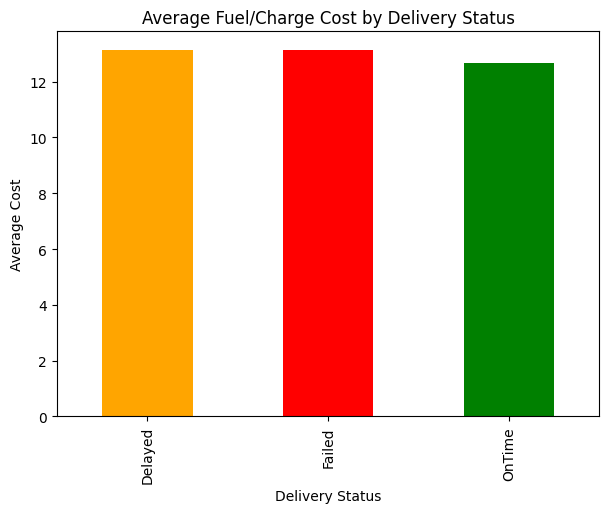

In [ ]:
# CHART 2 - Fuel/Charge Cost by Delivery Status
cost_analysis = deliveries.groupby(
    'delivery_status'
)['fuel_or_charge_cost'].mean()

plt.figure(figsize=(7,5))

cost_analysis.plot(kind='bar',
                   color=['orange','red','green'])

plt.title('Average Fuel/Charge Cost by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Average Cost')

plt.show()

In [ ]:
# Average fuel/charge cost by delivery status
cost_summary = deliveries.groupby('delivery_status')['fuel_or_charge_cost'].mean().reset_index()

# Rename column
cost_summary.columns = ['delivery_status', 'avg_fuel_charge_cost']

# Calculate percentage contribution
cost_summary['percentage'] = (
    cost_summary['avg_fuel_charge_cost']
    / cost_summary['avg_fuel_charge_cost'].sum()
    * 100
).round(1)

print(cost_summary)

  delivery_status  avg_fuel_charge_cost  percentage
0         Delayed             13.138713        33.7
1          Failed             13.147955        33.7
2          OnTime             12.678052        32.5


**Chart 3 - Complaint Severity Distribution**

This chart presents the distribution of complaint severity levels within the system. It helps identify the proportion of low, medium, and high-severity complaints, providing insights into customer service quality and the overall seriousness of operational issues.

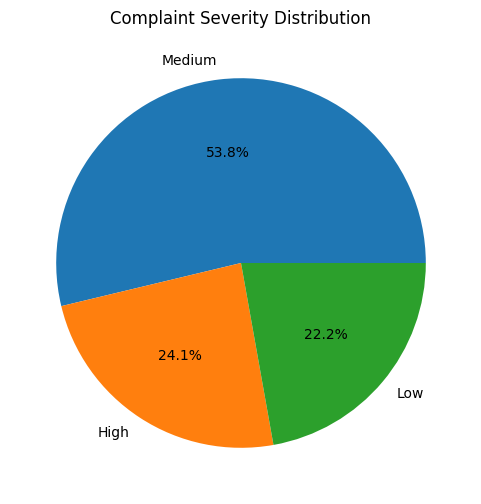

In [ ]:
# CHART 3 - Complaint Severity Distribution
severity = complaints['severity'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(severity.values,
        labels=severity.index,
        autopct='%1.1f%%')

plt.title('Complaint Severity Distribution')

plt.show()

**Chart 4 - Complaints by Type**

This chart displays the number of complaints for each complaint category within the NorthStar Urban Mobility system. It helps identify the most common customer issues and supports the company in prioritising areas that require operational or service improvements.

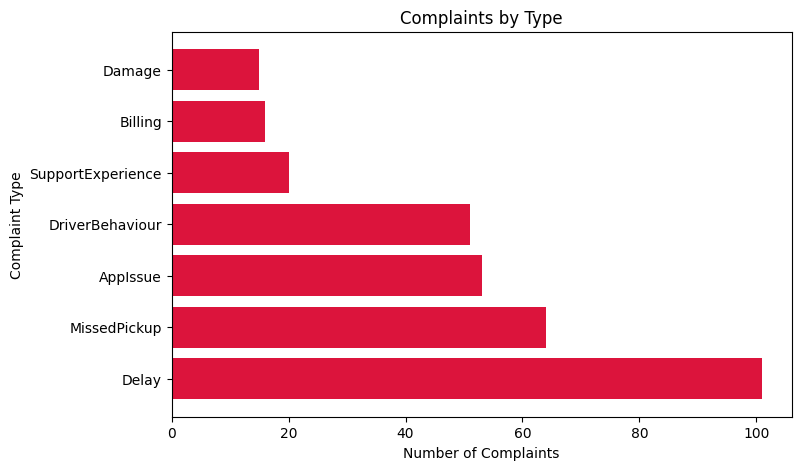

In [ ]:
# CHART 4 - Complaints by Type
complaint_counts = complaints['complaint_type'].value_counts()

plt.figure(figsize=(8,5))

plt.barh(complaint_counts.index,
         complaint_counts.values,
         color='crimson')

plt.title('Complaints by Type')
plt.xlabel('Number of Complaints')
plt.ylabel('Complaint Type')

plt.show()

In [ ]:
# Count complaints by type
complaint_summary = complaints['complaint_type'].value_counts().reset_index()

# Rename columns
complaint_summary.columns = ['complaint_type', 'total_complaints']

# Calculate percentage
complaint_summary['percentage'] = (
    complaint_summary['total_complaints']
    / complaint_summary['total_complaints'].sum()
    * 100
).round(1)

print(complaint_summary)

      complaint_type  total_complaints  percentage
0              Delay               101        31.6
1       MissedPickup                64        20.0
2           AppIssue                53        16.6
3    DriverBehaviour                51        15.9
4  SupportExperience                20         6.2
5            Billing                16         5.0
6             Damage                15         4.7


**Chart 5 - Average Customer Rating by Pickup Zone**

This chart analyses customer satisfaction levels across different pickup zones by calculating the average delivery rating for each area. The comparison helps identify high-performing and low-performing zones, enabling the company to improve service quality and operational efficiency in specific geographic regions.

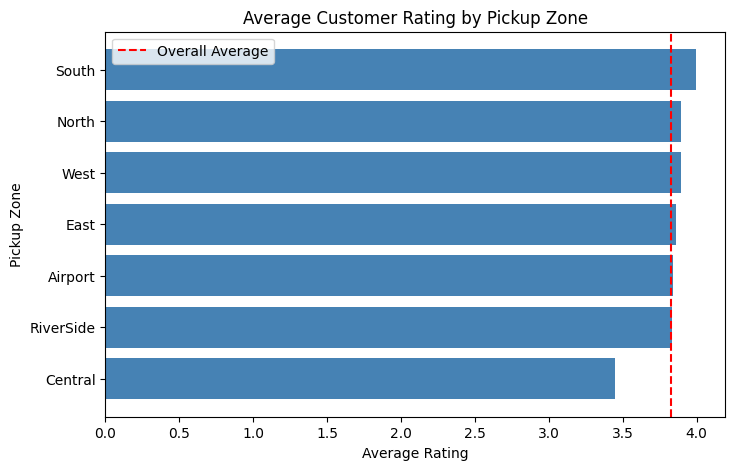

In [ ]:
# CHART 5 - Average Customer Rating by Pickup Zone
# Merge deliveries and orders datasets
delivery_orders = deliveries.merge(
    orders[['order_id', 'pickup_zone']],
    on='order_id',
    how='left'
)

# Calculate average rating for each zone
zone_rating = delivery_orders.groupby(
    'pickup_zone'
)['customer_rating_post_delivery'].mean().sort_values()

# Create chart
plt.figure(figsize=(8,5))

plt.barh(zone_rating.index,
         zone_rating.values,
         color='steelblue')

# Add average reference line
plt.axvline(zone_rating.mean(),
            color='red',
            linestyle='--',
            label='Overall Average')

plt.title('Average Customer Rating by Pickup Zone')
plt.xlabel('Average Rating')
plt.ylabel('Pickup Zone')

plt.legend()
plt.show()

In [ ]:
# Merge deliveries and orders
delivery_orders = deliveries.merge(
    orders[['order_id', 'pickup_zone']],
    on='order_id',
    how='left'
)

# Calculate average customer rating by zone
zone_rating_summary = delivery_orders.groupby(
    'pickup_zone'
)['customer_rating_post_delivery'].mean().reset_index()

# Rename column
zone_rating_summary.columns = ['pickup_zone', 'avg_customer_rating']

# Calculate percentage contribution
zone_rating_summary['percentage'] = (
    zone_rating_summary['avg_customer_rating']
    / zone_rating_summary['avg_customer_rating'].sum()
    * 100
).round(1)

# Sort values
zone_rating_summary = zone_rating_summary.sort_values(
    by='avg_customer_rating',
    ascending=False
)

print(zone_rating_summary)

  pickup_zone  avg_customer_rating  percentage
5       South             3.993525        14.9
3       North             3.896667        14.6
6        West             3.896316        14.6
2        East             3.861923        14.4
0     Airport             3.843009        14.4
4   RiverSide             3.832017        14.3
1     Central             3.444138        12.9


###**Deeper Analysis Charts**

**Chart 1 - Delivery Status Percentage by Service Type**

This chart compares the percentage of completed, delayed, and failed deliveries across different service types. It helps evaluate operational performance and identify which services experience higher failure or delay rates, supporting service quality improvement and resource planning.

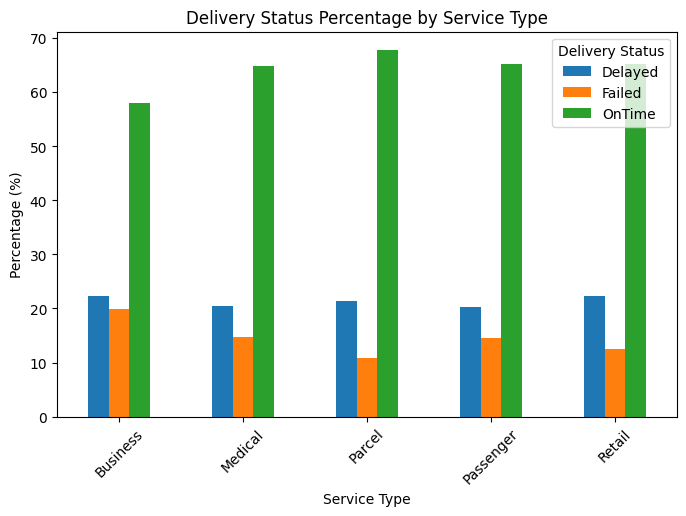

In [ ]:
# CHART 1 - Delivery Success/Failure Rate by Service Type
service_data = deliveries.merge(
    orders[['order_id', 'service_type']],
    on='order_id'
)

service_status = pd.crosstab(
    service_data['service_type'],
    service_data['delivery_status'],
    normalize='index'
) * 100

service_status.plot(kind='bar', figsize=(8,5))

plt.title('Delivery Status Percentage by Service Type')
plt.xlabel('Service Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Delivery Status')

plt.show()

**Chart 2 - Average Driver Rating by Delivery Outcome**

This chart analyses the relationship between driver ratings and delivery outcomes. It helps determine whether higher-rated drivers achieve better delivery performance and supports driver evaluation, training, and operational improvement strategies.

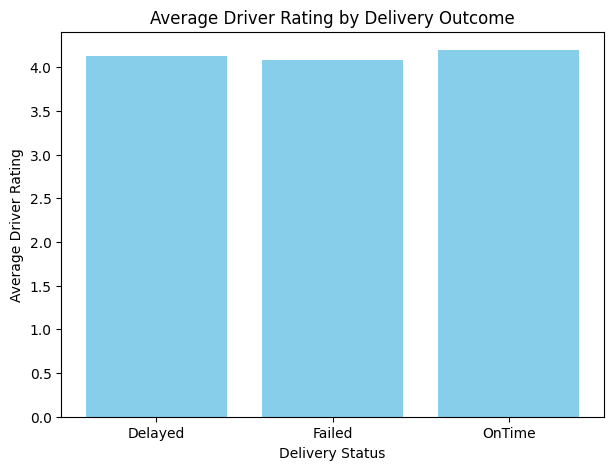

In [ ]:
# CHART 2 - Average Driver Rating by Delivery Outcome
driver_data = deliveries.merge(
    drivers[['driver_id', 'driver_rating']],
    on='driver_id'
)

rating_status = driver_data.groupby(
    'delivery_status'
)['driver_rating'].mean()

plt.figure(figsize=(7,5))

plt.bar(rating_status.index,
        rating_status.values,
        color='skyblue')

plt.title('Average Driver Rating by Delivery Outcome')
plt.xlabel('Delivery Status')
plt.ylabel('Average Driver Rating')

plt.show()

**Chart 3 - Incident Type Breakdown**

This chart presents the frequency of different incident types recorded in the NorthStar Urban Mobility system. It helps identify the most common operational incidents and supports risk management, safety monitoring, and process improvement initiatives.

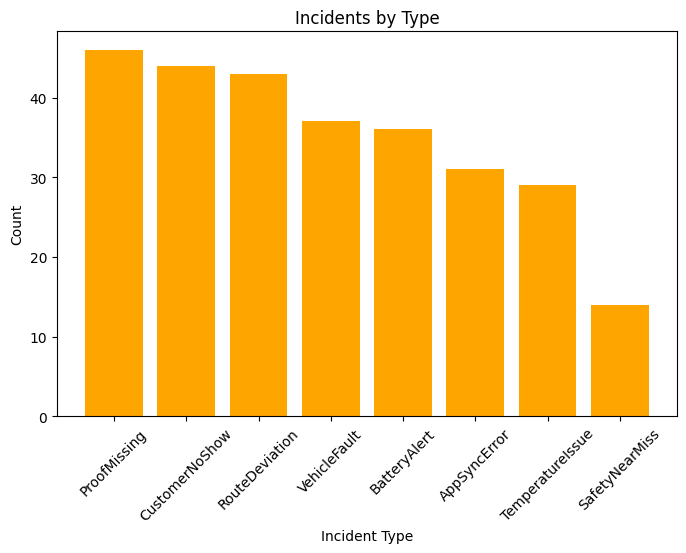

In [ ]:
# CHART 3 - Incident Type Breakdown
incident_counts = incidents['incident_type'].value_counts()

plt.figure(figsize=(8,5))

plt.bar(incident_counts.index,
        incident_counts.values,
        color='orange')

plt.title('Incidents by Type')
plt.xlabel('Incident Type')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

**Chart 4 - Monthly Order Volume Trend**

This chart analyses monthly order volumes to identify demand trends and seasonal variations in customer activity. The trend helps the company understand peak operational periods and supports better resource allocation and logistics planning.

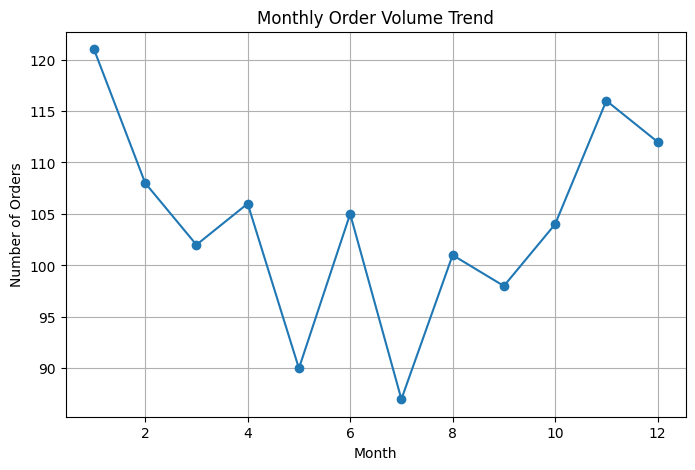

In [ ]:
# CHART 4 - Monthly Order Trend
orders['order_created_at'] = pd.to_datetime(
    orders['order_created_at']
)

orders['order_month'] = orders['order_created_at'].dt.month

monthly_orders = orders.groupby(
    'order_month'
).size()

plt.figure(figsize=(8,5))

plt.plot(monthly_orders.index,
         monthly_orders.values,
         marker='o')

plt.title('Monthly Order Volume Trend')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

plt.grid(True)

plt.show()